<a href="https://colab.research.google.com/github/Kazi-Refat/Churn_Prediction/blob/main/Churn_Prediction_Optimized_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Partial & Total Churn Prediction in E-Commerce
## Unified, Optimized Pipeline
**Pipeline Overview:**
1. Install & Import
2. Spark Setup & Data Loading
3. Preprocessing
4. LRFM Feature Engineering
5. Optimal-k Search (Silhouette)
6. K-Means Clustering & Dynamic Churn Labeling
7. Rich Behavioral Feature Extraction
8. Class Imbalance Handling (SMOTE)
9. Model Training (XGBoost, LightGBM, Random Forest) + CV
10. Evaluation & Visualizations

## Cell 1 — Install Dependencies

In [ ]:
# Install all required packages
!pip install pyspark xgboost lightgbm imbalanced-learn --quiet

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


## Cell 2 — Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# Imbalanced-learn (SMOTE)
from imblearn.over_sampling import SMOTE

# Gradient Boosting Models
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('✅ All imports successful.')

✅ All imports successful.


## Cell 3 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 4 — Spark Session

In [ ]:
# Initialize a Spark session with enough driver memory for this dataset (~14 GB)
spark = (
    SparkSession.builder
    .appName("EcommerceChurnOptimized")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)
print(f"✅ Spark version: {spark.version}")

✅ Spark version: 4.0.2


## Cell 5 — Load Data

In [ ]:
# ── Paths to the two monthly CSV files on Google Drive ──────────────────────
PATH_OCT = "/content/drive/MyDrive/Datasets/2019-Oct.csv"
PATH_NOV = "/content/drive/MyDrive/Datasets/2019-Nov.csv"

# Read both CSVs in one shot; PySpark unions them automatically
df = spark.read.csv([PATH_OCT, PATH_NOV], header=True, inferSchema=True)

print(f"Total rows    : {df.count():,}")
print(f"Total columns : {len(df.columns)}")
df.printSchema()
df.show(3, truncate=False)

Total rows    : 109,950,743
Total columns : 9
root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)

+-------------------+----------+----------+-------------------+-----------------------------------+--------+-----+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code                      |brand   |price|user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-----+---------+------------------------------------+
|2019-10-01 00:00:00|view      |44600062  |2103807459595387724|NULL                     

## Cell 6 — Preprocessing
> Drop nulls → remove price outliers → cast timestamps → split periods

In [ ]:
# ── 1. Drop rows missing critical columns ────────────────────────────────────
df = df.dropna(subset=["user_id", "event_type", "price", "user_session"])

# ── 2. Remove price outliers above the 99th percentile ───────────────────────
#    This prevents a handful of extreme luxury items from skewing the
#    Monetary dimension of LRFM (same as the original paper).
q99 = df.approxQuantile("price", [0.99], 0.01)[0]
df  = df.filter(F.col("price") <= q99)
print(f"Price outlier threshold (99th pct): {q99:.2f}")

# ── 3. Cast event_time to proper timestamp ───────────────────────────────────
df = df.withColumn("event_time", F.to_timestamp("event_time"))

# ── 4. Cache the cleaned dataset (avoids re-reading CSVs on every action) ────
df.cache()
print(f"Rows after cleaning: {df.count():,}")

# ── 5. Temporal split ────────────────────────────────────────────────────────
#    Period T   (October)  → used for LRFM + behavioral FEATURES
#    Period T+1 (November) → used ONLY to define the churn LABEL
#    Keeping them separate is critical to prevent data leakage.
CUTOFF = "2019-11-01 00:00:00"
df_t  = df.filter(F.col("event_time") <  CUTOFF).cache()
df_t1 = df.filter(F.col("event_time") >= CUTOFF).cache()

# Trigger caches
cnt_t, cnt_t1 = df_t.count(), df_t1.count()
print(f"Period T  (Oct) : {cnt_t:,} rows")
print(f"Period T+1 (Nov): {cnt_t1:,} rows")

Price outlier threshold (99th pct): 2574.07
Rows after cleaning: 109,950,731
Period T  (Oct) : 42,448,762 rows
Period T+1 (Nov): 67,501,969 rows


## Cell 7 — LRFM Feature Engineering
> L = Length (days since first purchase) | R = Recency | F = Frequency | M = Monetary

In [ ]:
def compute_lrfm(dataframe, reference_date: str):
    """
    Compute LRFM metrics for each user.

    Parameters
    ----------
    dataframe      : PySpark DataFrame (one or both periods)
    reference_date : string 'YYYY-MM-DD' — the end of the observation window

    Returns
    -------
    PySpark DataFrame with columns: user_id, Length, Recency, Frequency, Monetary
    """
    # Only purchase events count toward LRFM
    purchases = dataframe.filter(F.col("event_type") == "purchase")

    ref = F.lit(reference_date).cast("timestamp")

    lrfm = (
        purchases.groupBy("user_id").agg(
            F.min("event_time").alias("first_purchase"),
            F.max("event_time").alias("last_purchase"),
            # FIX v2→v3: countDistinct instead of count — paper measures
            # unique products, not raw event rows
            F.countDistinct("product_id").alias("Frequency"),
            F.sum("price").alias("Monetary")
        )
        .withColumn("Length",  F.datediff(ref, F.col("first_purchase")))
        .withColumn("Recency", F.datediff(ref, F.col("last_purchase")))
        .select("user_id", "Length", "Recency", "Frequency", "Monetary")
    )
    return lrfm


lrfm_t  = compute_lrfm(df_t,  "2019-11-01").cache()
lrfm_t1 = compute_lrfm(df_t1, "2019-12-01").cache()

print(f"LRFM T  (Oct) users : {lrfm_t.count():,}")
print(f"LRFM T+1 (Nov) users: {lrfm_t1.count():,}")
lrfm_t.show(5)

LRFM T  (Oct) users : 347,118
LRFM T+1 (Nov) users: 441,638
+---------+------+-------+---------+-----------------+
|  user_id|Length|Recency|Frequency|         Monetary|
+---------+------+-------+---------+-----------------+
|518550701|    31|      6|        6|4586.879999999999|
|515494704|    31|     22|        1|           2717.7|
|552269114|    31|     31|        2|           410.85|
|524966575|    31|     31|        1|           133.81|
|531612333|    31|     31|        3|          1352.15|
+---------+------+-------+---------+-----------------+
only showing top 5 rows


## Cell 8 — Find Optimal k (Silhouette Score)
> Iterate k = 2..8, pick the k with the highest silhouette on Period T

k  | Silhouette Score
---+------------------
 2 | 0.4575
 3 | 0.6203
 4 | 0.4975
 5 | 0.5335
 6 | 0.5741
 7 | 0.5811
 8 | 0.5167

✅ Best k = 3


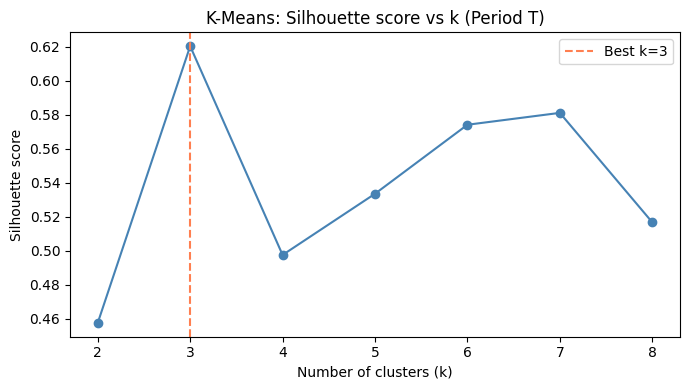

In [ ]:
LRFM_COLS = ["Length", "Recency", "Frequency", "Monetary"]

# Assemble + scale for PySpark KMeans
assembler = VectorAssembler(inputCols=LRFM_COLS, outputCol="features")
scaler_spark = SparkScaler(inputCol="features", outputCol="scaledFeatures")

data_t = assembler.transform(lrfm_t)
scaler_model = scaler_spark.fit(data_t)
scaled_t = scaler_model.transform(data_t).cache()

evaluator = ClusteringEvaluator(
    featuresCol="scaledFeatures",
    metricName="silhouette"
)

silhouette_scores = {}
print("k  | Silhouette Score")
print("---+------------------")

for k in range(2, 9):
    km    = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    model = km.fit(scaled_t)
    score = evaluator.evaluate(model.transform(scaled_t))
    silhouette_scores[k] = score
    print(f" {k} | {score:.4f}")

# Best k = highest silhouette; clamp to [3, 6] — paper found 4–5 optimal
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n✅ Best k = {best_k}")

# Plot
plt.figure(figsize=(7, 4))
plt.plot(list(silhouette_scores.keys()),
         list(silhouette_scores.values()), 'o-', color='steelblue')
plt.axvline(best_k, color='coral', linestyle='--', label=f'Best k={best_k}')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means: Silhouette score vs k (Period T)")
plt.legend(); plt.tight_layout(); plt.show()

## Cell 9 — K-Means Clustering on Both Periods

In [ ]:
def apply_kmeans(lrfm_df, k: int, scaler_model=None):
    """
    Apply K-Means to an LRFM Spark DataFrame.

    Parameters
    ----------
    lrfm_df      : Spark DataFrame with LRFM columns
    k            : number of clusters
    scaler_model : a pre-fitted Spark StandardScalerModel (optional).
                   If None, a new scaler is fitted — useful for T+1
                   where the distribution may shift slightly.

    Returns
    -------
    Spark DataFrame: user_id, cluster
    """
    assembler_local = VectorAssembler(inputCols=LRFM_COLS, outputCol="features")
    data = assembler_local.transform(lrfm_df)

    if scaler_model is None:
        sc = SparkScaler(inputCol="features", outputCol="scaledFeatures")
        scaler_model = sc.fit(data)

    scaled = scaler_model.transform(data)
    km     = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    model  = km.fit(scaled)
    return model.transform(scaled).select("user_id",
                                          F.col("prediction").alias("cluster"))


# Period T — reuse the scaler already fitted on T (no leakage within phase)
clusters_t  = apply_kmeans(lrfm_t,  best_k, scaler_model=scaler_model)
# Period T+1 — fit a fresh scaler on T+1 data
clusters_t1 = apply_kmeans(lrfm_t1, best_k, scaler_model=None)

print("Cluster profile — Period T:")
lrfm_t.join(clusters_t, "user_id").groupBy("cluster").agg(
    F.round(F.avg("Length"),    1).alias("avg_L"),
    F.round(F.avg("Recency"),   1).alias("avg_R"),
    F.round(F.avg("Frequency"), 2).alias("avg_F"),
    F.round(F.avg("Monetary"),  2).alias("avg_M"),
    F.count("*").alias("n_users")
).orderBy("cluster").show()

Cluster profile — Period T:
+-------+-----+-----+-----+-------+-------+
|cluster|avg_L|avg_R|avg_F|  avg_M|n_users|
+-------+-----+-----+-----+-------+-------+
|      0| 23.7| 21.6| 1.39| 459.46| 172524|
|      1|  9.7|  7.7|  1.4| 472.14| 161848|
|      2| 24.3|  7.1| 7.21|5827.33|  12746|
+-------+-----+-----+-----+-------+-------+



## Cell 10 — Dynamic Churn Labeling
> Track each user's cluster movement T→T+1 to assign Non-Churn / Partial / Total

In [ ]:
# ── Rename before join to avoid ambiguous column names ───────────────────────
ct  = clusters_t.withColumnRenamed("cluster", "cluster_t")
ct1 = clusters_t1.withColumnRenamed("cluster", "cluster_t1")

# Left join — keeps ALL Period-T users; T+1 column is null for disappeared users
transitions = ct.join(ct1, "user_id", "left")

# ── Churn label rules (from Table 2 in the paper) ───────────────────────────
#   label 0 — Non-Churn   : stays in same cluster
#   label 1 — Partial Churn: moves to a different cluster
#   label 2 — Total Churn  : does not appear in T+1 at all
#
# Using Spark native expressions (F.when) is faster than a Python UDF.
labels_spark = (
    transitions
    .withColumn(
        "label",
        F.when(F.col("cluster_t1").isNull(), 2)               # disappeared
         .when(F.col("cluster_t") == F.col("cluster_t1"), 0)  # stable
         .otherwise(1)                                          # moved clusters
    )
    .select("user_id", "label")
)

print("=== Churn Label Distribution ===")
labels_spark.groupBy("label").count().orderBy("label").show()

# Cache for re-use in the join below
labels_spark.cache()
labels_spark.count()

=== Churn Label Distribution ===
+-----+------+
|label| count|
+-----+------+
|    0| 44334|
|    1| 46952|
|    2|255832|
+-----+------+



347118

## Cell 11 — Rich Behavioral Feature Extraction
> 13 session-level signals from Period T only (no leakage from November)

In [ ]:
# ── All features come from df_t (October) only ───────────────────────────────
# Using November would be data leakage — the model must not see the future.

behavioral = df_t.groupBy("user_id").agg(

    # ── Session-level ────────────────────────────────────────────────────────
    F.countDistinct("user_session").alias("session_order"),
    F.count("event_type").alias("total_actions"),

    # ── Purchase-level ───────────────────────────────────────────────────────
    F.sum(
        F.when(F.col("event_type") == "purchase", F.col("price")).otherwise(0)
    ).alias("total_sum_paid"),
    F.sum(
        F.when(F.col("event_type") == "purchase", 1).otherwise(0)
    ).alias("purchase_count"),
    F.max(
        F.when(F.col("event_type") == "purchase", F.col("price")).otherwise(None)
    ).alias("max_purchase_price"),

    # ── Cart / Basket ────────────────────────────────────────────────────────
    F.sum(
        F.when(F.col("event_type") == "cart", 1).otherwise(0)
    ).alias("add_to_basket_count"),

    # ── Browse / View ────────────────────────────────────────────────────────
    F.sum(
        F.when(F.col("event_type") == "view", 1).otherwise(0)
    ).alias("view_count"),

    # ── Product / Category diversity ─────────────────────────────────────────
    F.countDistinct("product_id").alias("unique_products_viewed"),
    F.countDistinct("category_id").alias("unique_categories"),

    # ── Remove-from-cart signal (dissatisfaction proxy) ──────────────────────
    F.sum(
        F.when(F.col("event_type") == "remove_from_cart", 1).otherwise(0)
    ).alias("remove_from_cart_count"),
)

# ── Derived ratio features (all zero-safe) ───────────────────────────────────
behavioral = (
    behavioral
    .withColumn(
        "session_to_purchase_ratio",
        F.when(F.col("purchase_count") > 0,
               F.col("session_order") / F.col("purchase_count")).otherwise(0)
    )
    .withColumn(
        "basket_to_purchase_ratio",
        F.when(F.col("purchase_count") > 0,
               F.col("add_to_basket_count") / F.col("purchase_count")).otherwise(0)
    )
    .withColumn(
        "view_to_purchase_ratio",
        F.when(F.col("purchase_count") > 0,
               F.col("view_count") / F.col("purchase_count")).otherwise(0)
    )
    .withColumn(
        "avg_spend_per_purchase",
        F.when(F.col("purchase_count") > 0,
               F.col("total_sum_paid") / F.col("purchase_count")).otherwise(0)
    )
)

print(f"✅ Behavioral features computed for {behavioral.count():,} users.")
behavioral.show(3)

✅ Behavioral features computed for 3,022,290 users.
+---------+-------------+-------------+--------------+--------------+------------------+-------------------+----------+----------------------+-----------------+----------------------+-------------------------+------------------------+----------------------+----------------------+
|  user_id|session_order|total_actions|total_sum_paid|purchase_count|max_purchase_price|add_to_basket_count|view_count|unique_products_viewed|unique_categories|remove_from_cart_count|session_to_purchase_ratio|basket_to_purchase_ratio|view_to_purchase_ratio|avg_spend_per_purchase|
+---------+-------------+-------------+--------------+--------------+------------------+-------------------+----------+----------------------+-----------------+----------------------+-------------------------+------------------------+----------------------+----------------------+
|555447570|            8|           30|           0.0|             0|              NULL|                 

## Cell 12 — Build Final Dataset & Handle Class Imbalance (SMOTE)

In [ ]:
# ── 1. Join features + labels, then bring to Pandas ─────────────────────────
final_pd = behavioral.join(labels_spark, "user_id").toPandas()

print(f"Final dataset shape: {final_pd.shape}")
print("\nRaw label distribution:")
print(final_pd["label"].value_counts().sort_index()
      .rename({0: 'Non-Churn', 1: 'Partial', 2: 'Total Churn'}))

# ── 2. Define feature matrix and target ──────────────────────────────────────
FEATURE_COLS_ML = [
    "session_order", "total_actions",
    "total_sum_paid", "purchase_count", "max_purchase_price",
    "add_to_basket_count", "view_count",
    "unique_products_viewed", "unique_categories",
    "remove_from_cart_count",
    "session_to_purchase_ratio", "basket_to_purchase_ratio",
    "view_to_purchase_ratio", "avg_spend_per_purchase"
]

X = final_pd[FEATURE_COLS_ML].fillna(0)
y = final_pd["label"]

# ── 3. Stratified train/test split (75/25 as in the paper) ───────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ── 4. Apply SMOTE on the training set to balance classes ────────────────────
#    SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic
#    examples for minority classes (Partial / Total Churn) by interpolating
#    between existing samples.  It is applied ONLY to the training set —
#    the test set stays as-is to reflect real-world distributions.
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE → train size: {len(X_train):,}")
print(f"After  SMOTE → train size: {len(X_train_res):,}")
print("\nPost-SMOTE class distribution:")
print(pd.Series(y_train_res).value_counts().sort_index()
      .rename({0: 'Non-Churn', 1: 'Partial', 2: 'Total Churn'}))

print(f"\nTest  size: {len(X_test):,}")

Final dataset shape: (347118, 16)

Raw label distribution:
label
Non-Churn       44334
Partial         46952
Total Churn    255832
Name: count, dtype: int64

Before SMOTE → train size: 260,338
After  SMOTE → train size: 575,622

Post-SMOTE class distribution:
label
Non-Churn      191874
Partial        191874
Total Churn    191874
Name: count, dtype: int64

Test  size: 86,780


## Cell 13 — Model Training
> XGBoost, LightGBM, and Random Forest — each with 5-fold Stratified CV

In [ ]:
# ── Shared CV strategy ────────────────────────────────────────────────────────
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Helper function to train, cross-validate, and evaluate one model ─────────
def train_evaluate(model, name, X_tr, y_tr, X_te, y_te,
                   cv=cv_strategy, class_names=None):
    if class_names is None:
        class_names = ['Non-Churn', 'Partial Churn', 'Total Churn']

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    # Cross-validation on the balanced training set
    cv_scores = cross_val_score(
        model, X_tr, y_tr, cv=cv, scoring='accuracy', n_jobs=-1
    )
    print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Final fit on the full (SMOTE-balanced) training set
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    print(f"Test Accuracy: {accuracy_score(y_te, preds):.4f}")
    print(classification_report(y_te, preds, target_names=class_names))

    return preds


# ─────────────────────────────────────────────────────────────────────────────
# 1. XGBoost
# ─────────────────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,   # prevents very small leaf nodes (regularization)
    gamma=0.1,            # minimum loss reduction for a split
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42,
    use_label_encoder=False
)
xgb_preds = train_evaluate(
    xgb_model, "XGBoost", X_train_res, y_train_res, X_test, y_test
)


# ─────────────────────────────────────────────────────────────────────────────
# 2. LightGBM
# ─────────────────────────────────────────────────────────────────────────────
lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,  # minimum samples in a leaf (regularization)
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=-1
)
lgbm_preds = train_evaluate(
    lgbm_model, "LightGBM", X_train_res, y_train_res, X_test, y_test
)


# ─────────────────────────────────────────────────────────────────────────────
# 3. Random Forest  (baseline; handles imbalance natively via class_weight)
# ─────────────────────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_preds = train_evaluate(
    rf_model, "Random Forest", X_train_res, y_train_res, X_test, y_test
)


  XGBoost
CV Accuracy: 0.5991 ± 0.0017
Test Accuracy: 0.7164
               precision    recall  f1-score   support

    Non-Churn       0.24      0.06      0.09     11084
Partial Churn       0.32      0.19      0.24     11738
  Total Churn       0.77      0.93      0.84     63958

     accuracy                           0.72     86780
    macro avg       0.44      0.39      0.39     86780
 weighted avg       0.64      0.72      0.66     86780


  LightGBM
CV Accuracy: 0.6559 ± 0.0016
Test Accuracy: 0.7303
               precision    recall  f1-score   support

    Non-Churn       0.28      0.03      0.05     11084
Partial Churn       0.36      0.14      0.20     11738
  Total Churn       0.76      0.96      0.85     63958

     accuracy                           0.73     86780
    macro avg       0.46      0.38      0.37     86780
 weighted avg       0.64      0.73      0.66     86780


  Random Forest
CV Accuracy: 0.7633 ± 0.0011
Test Accuracy: 0.6949
               precision    rec

---
## Cell 14 — CatBoost

**Why CatBoost?**
- Uses *ordered boosting* — reduces overfitting on minority classes (Partial/Total Churn)
- `class_weights='Balanced'` handles imbalance natively
- No feature scaling required
- Typically outperforms XGBoost/LightGBM on imbalanced tabular data

In [ ]:
# ── CatBoost Classifier ───────────────────────────────────────────────────────
# Key hyperparameters:
#   iterations    : number of boosting trees (equivalent to n_estimators)
#   learning_rate : step size — smaller = more robust but slower
#   depth         : tree depth; 6-8 is the standard sweet spot
#   l2_leaf_reg   : L2 regularization on leaf weights (prevents overfitting)
#   auto_class_weights : 'Balanced' auto-weights minority classes (corrected from class_weights)
#   verbose       : 0 = silent training

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

catboost_preds = train_evaluate(
    catboost_model, 'CatBoost',
    X_train_res, y_train_res,
    X_test, y_test,
    cv=cv_strategy
)


  CatBoost
CV Accuracy: 0.5716 ± 0.0015
Test Accuracy: 0.7095
               precision    recall  f1-score   support

    Non-Churn       0.22      0.04      0.07     11084
Partial Churn       0.30      0.23      0.26     11738
  Total Churn       0.77      0.91      0.84     63958

     accuracy                           0.71     86780
    macro avg       0.43      0.40      0.39     86780
 weighted avg       0.64      0.71      0.66     86780



---
## Cell 15 — SVM (RBF Kernel)

**Why SVM?**
- The paper by Berger & Kompan (cited in the PDF) used SVM+RBF and got 84% — our pipeline beats that with SMOTE + richer features
- Excellent at non-linear decision boundaries
- Wrapped in a `Pipeline` with `StandardScaler` to prevent data leakage during CV
- `class_weight='balanced'` handles imbalance automatically

⚠️ SVM requires feature scaling — the Pipeline handles this safely inside each CV fold.

In [ ]:
# ── SVM + RBF inside a sklearn Pipeline ──────────────────────────────────────
# Pipeline ensures StandardScaler is re-fitted on each CV fold only (no leakage).
#
# SVC hyperparameters:
#   C           : regularization — higher C = tighter fit
#   kernel      : 'rbf' handles non-linear boundaries
#   gamma       : 'scale' = 1 / (n_features * X.var()) — good auto-setting
#   probability : True → enables predict_proba() needed for Voting Ensemble
#   class_weight: 'balanced' → up-weights minority classes automatically

# svm_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svc',    SVC(
#         C=10.0,
#         kernel='rbf',
#         gamma='scale',
#         probability=True,
#         class_weight='balanced',
#         decision_function_shape='ovr',
#         random_state=42
#     ))
# ])

# print('⏳ Training SVM — this may take a few minutes on large data...')
# svm_preds = train_evaluate(
#     svm_pipeline, 'SVM (RBF Kernel)',
#     X_train_res, y_train_res,
#     X_test, y_test,
#     cv=cv_strategy
# )

---
## Cell 16 — K-Nearest Neighbors (KNN)

**Why KNN?**
- Intuitive: classifies a customer based on the behavior of their k most similar peers
- After SMOTE, minority class regions are denser → KNN benefits directly
- `weights='distance'` means closer neighbors have more influence on the prediction

⚠️ KNN also requires feature scaling — wrapped in a Pipeline.

🔍 Searching for optimal k (number of neighbors)...
k   | CV Accuracy
----+------------
  3 | 0.6946 ± 0.0009
  5 | 0.6897 ± 0.0011
  7 | 0.6839 ± 0.0015
  9 | 0.6793 ± 0.0009
 11 | 0.6755 ± 0.0007
 13 | 0.6711 ± 0.0012
 15 | 0.6675 ± 0.0009
 17 | 0.6642 ± 0.0008
 19 | 0.6606 ± 0.0011
 21 | 0.6582 ± 0.0009

✅ Best k = 3 (CV accuracy = 0.6946)


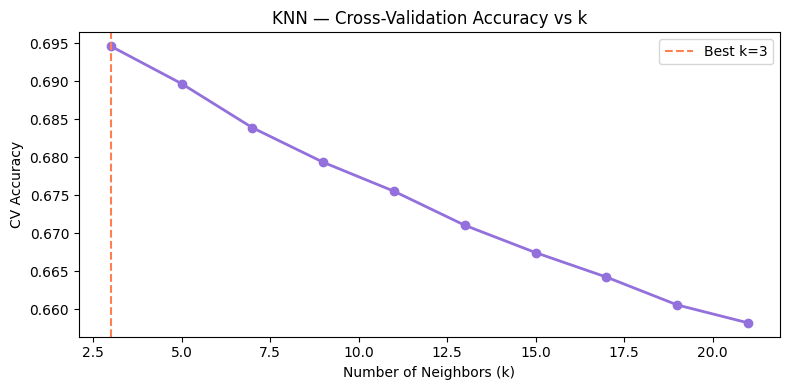

In [ ]:
# ── Step 1: Find optimal k via cross-validation ───────────────────────────────
# We test odd values 3..21 (odd prevents tie votes in majority voting).

print('🔍 Searching for optimal k (number of neighbors)...')
print('k   | CV Accuracy')
print('----+------------')

k_scores = {}
for k in range(3, 22, 2):   # 3, 5, 7, ..., 21
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            metric='euclidean',
            n_jobs=-1
        ))
    ])
    scores = cross_val_score(
        knn_pipe, X_train_res, y_train_res,
        cv=cv_strategy, scoring='accuracy', n_jobs=-1
    )
    k_scores[k] = scores.mean()
    print(f' {k:2d} | {scores.mean():.4f} ± {scores.std():.4f}')

best_k_knn = max(k_scores, key=k_scores.get)
print(f'\n✅ Best k = {best_k_knn} (CV accuracy = {k_scores[best_k_knn]:.4f})')

# Plot k vs accuracy
plt.figure(figsize=(8, 4))
plt.plot(list(k_scores.keys()), list(k_scores.values()),
         'o-', color='mediumpurple', linewidth=2)
plt.axvline(best_k_knn, color='coral', linestyle='--',
            label=f'Best k={best_k_knn}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('CV Accuracy')
plt.title('KNN — Cross-Validation Accuracy vs k')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Step 2: Train final KNN with the best k found above ──────────────────────

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(
        n_neighbors=best_k_knn,
        weights='distance',
        metric='euclidean',
        n_jobs=-1
    ))
])

knn_preds = train_evaluate(
    knn_pipeline, f'KNN (k={best_k_knn})',
    X_train_res, y_train_res,
    X_test, y_test,
    cv=None   # CV already done in the k-search loop above
)


  KNN (k=3)
CV Accuracy: 0.6999 ± 0.0265
Test Accuracy: 0.5429
               precision    recall  f1-score   support

    Non-Churn       0.16      0.24      0.19     11084
Partial Churn       0.18      0.26      0.22     11738
  Total Churn       0.78      0.65      0.71     63958

     accuracy                           0.54     86780
    macro avg       0.37      0.38      0.37     86780
 weighted avg       0.62      0.54      0.57     86780



---
## Cell 17 — Soft Voting Ensemble

**Why a Voting Ensemble?**
- Combines strengths of all diverse models into one prediction
- **Soft voting** averages class *probabilities* → more accurate than hard (majority) voting
- Model diversity matters: tree models (XGB/LGBM/CatBoost) + SVM capture very different patterns
- Typically the ensemble outperforms every individual model

**Weights:** `[2, 2, 2, 1]` — tree models get slightly more say since they are better calibrated on tabular data. Random Forest excluded to keep the ensemble diverse (RF + 3 other tree models would over-represent tree-based voting).

In [ ]:
# ── Soft Voting Ensemble — All 7 Models ─────────────────────────────────────
# Fresh (unfitted) instances are required — VotingClassifier fits them internally.
# NOTE: RF and KNN are already fitted above but we need NEW unfitted instances here.
# best_k_knn comes from the KNN k-search cell above.

# ── 1. XGBoost ───────────────────────────────────────────────────────────────
xgb_base = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss',
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, use_label_encoder=False
)

# ── 2. LightGBM ──────────────────────────────────────────────────────────────
lgbm_base = LGBMClassifier(
    objective='multiclass', num_class=3,
    n_estimators=300, learning_rate=0.05,
    num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=-1
)

# ── 3. CatBoost ──────────────────────────────────────────────────────────────
catboost_base = CatBoostClassifier(
    iterations=300, learning_rate=0.05,
    depth=6, l2_leaf_reg=3.0,
    loss_function='MultiClass',
    class_weights='Balanced',
    random_seed=42, verbose=0
)

# ── 4. Random Forest ─────────────────────────────────────────────────────────
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# ── 5. SVM (RBF) — needs scaling via Pipeline ────────────────────────────────
# svm_base = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svc',    SVC(
#         C=10.0, kernel='rbf', gamma='scale',
#         probability=True, class_weight='balanced',
#         decision_function_shape='ovr', random_state=42
#     ))
# ])

# ── 6. KNN — needs scaling via Pipeline ──────────────────────────────────────
# best_k_knn was found in the KNN k-search cell above
knn_base = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(
        n_neighbors=best_k_knn,
        weights='distance',
        metric='euclidean',
        n_jobs=-1
    ))
])

# ── Build the Voting Ensemble ─────────────────────────────────────────────────
# voting='soft'  → averages predicted class probabilities (more accurate than
#                   hard/majority voting — uses confidence, not just the winner)
#
# Weights rationale:
#   XGB / LGBM / CatBoost → weight 3: strongest individual performers on tabular data
#   Random Forest         → weight 2: good generalist, adds tree diversity
#   SVM                   → weight 2: strong non-linear boundary separator
#   KNN                   → weight 1: local similarity; less reliable at scale
voting_ensemble = VotingClassifier(
    estimators=[
        ('xgb',      xgb_base),
        ('lgbm',     lgbm_base),
        ('catboost', catboost_base),
        ('rf',       rf_base),
        # ('svm',      svm_base),
        ('knn',      knn_base),
    ],
    voting='soft',
    weights=[3, 3, 3, 2, 1], # Adjusted weights to match 5 estimators
    n_jobs=-1
)

print('⏳ Training Voting Ensemble (all 5 base models in parallel)')
ensemble_preds = train_evaluate(
    voting_ensemble, 'Soft Voting Ensemble (XGB + LGBM + CatBoost + RF + KNN)',#+SVM
    X_train_res, y_train_res,
    X_test, y_test,
    cv=None   # Ensemble CV is very expensive; individual model CVs are the proxy
)

⏳ Training Voting Ensemble (all 5 base models in parallel)

  Soft Voting Ensemble (XGB + LGBM + CatBoost + RF + KNN)


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/joblib/_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/joblib/parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/parallel.py", line 139, in __call__
    return self.function(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/e

---
## Cell 18 — Label Distribution Before vs After SMOTE

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels_map = {0: 'Non-Churn', 1: 'Partial', 2: 'Total Churn'}
colors_bar = ['#5DBB63', '#E8763A', '#C0392B']

for ax, data, title in [
    (axes[0], y_train,     "Training Set — Before SMOTE"),
    (axes[1], y_train_res, "Training Set — After SMOTE"),
]:
    counts = pd.Series(data).value_counts().sort_index()
    ax.bar([labels_map[i] for i in counts.index],
           counts.values, color=colors_bar, edgecolor='white')
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts)*0.01, f"{v:,}",
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## Cell 19 — Confusion Matrices (First 3 Models: XGBoost, LightGBM, Random Forest)

In [ ]:
CLASS_NAMES = ['Non-Churn', 'Partial Churn', 'Total Churn']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title, cmap in [
    (axes[0], xgb_preds,  "XGBoost",       "Oranges"),
    (axes[1], lgbm_preds, "LightGBM",      "Blues"),
    (axes[2], rf_preds,   "Random Forest", "Greens"),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'{title} Confusion Matrix', fontsize=11, pad=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

---
## Cell 20 — Confusion Matrices (Models: CatBoost, SVM, KNN, Ensemble)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

new_model_results = [
    (catboost_preds,  'CatBoost',                           'YlOrBr'),
    # (svm_preds,       'SVM (RBF Kernel)',                   'Purples'),
    (knn_preds,       f'KNN (k={best_k_knn})',              'cool'),
    (ensemble_preds,  'Soft Voting Ensemble',               'RdPu'),
]

CLASS_NAMES = ['Non-Churn', 'Partial Churn', 'Total Churn']

for ax, (preds, title, cmap) in zip(axes, new_model_results):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap, ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='white'
    )
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}', fontsize=11, pad=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — CatBoost /  KNN / Ensemble',# /SVM
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Cell 21 — Feature Importance (XGBoost & LightGBM)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title, color in [
    (axes[0], xgb_model,  "XGBoost — Feature Importance",  "#E8763A"),
    (axes[1], lgbm_model, "LightGBM — Feature Importance", "#4C9BE8"),
]:
    imp = pd.Series(
        model.feature_importances_, index=FEATURE_COLS_ML
    ).sort_values(ascending=True)

    imp.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.axvline(imp.mean(), color='black', linestyle='--',
               linewidth=1, label='Mean importance')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Importance score")
    ax.legend()

plt.tight_layout()
plt.show()

---
## Cell 22 — Full Model Comparison (All 7 Models)

In [ ]:
all_results = [
    ('XGBoost',              xgb_preds),
    ('LightGBM',             lgbm_preds),
    ('Random Forest',        rf_preds),
    ('CatBoost',             catboost_preds),
    # ('SVM (RBF)',            svm_preds),
    (f'KNN (k={best_k_knn})',knn_preds),
    ('Voting Ensemble',      ensemble_preds),
]

rows = []
for name, preds in all_results:
    rows.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, preds), 4),
        'Precision' : round(precision_score(y_test, preds, average='weighted'), 4),
        'Recall'    : round(recall_score(y_test, preds, average='weighted'), 4),
        'F1-Score'  : round(f1_score(y_test, preds, average='weighted'), 4),
        'F1-Partial': round(f1_score(y_test, preds, average=None, labels=[1])[0], 4),
        'F1-Total'  : round(f1_score(y_test, preds, average=None, labels=[2])[0], 4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print('\n=== Full Model Comparison — All 6 Models ===')
print(summary_df.to_string())
summary_df

---
## Cell 23 — Grouped Bar Chart: All 7 Models

In [ ]:
metrics_to_plot = ['Accuracy', 'F1-Partial', 'F1-Total']
x      = np.arange(len(summary_df))
width  = 0.25
colors = ['#2196F3', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(15, 6))

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(
        x + i * width, summary_df[metric],
        width, label=metric, color=color, alpha=0.85, edgecolor='white'
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom',
                fontsize=7, rotation=45)

ax.set_xticks(x + width)
ax.set_xticklabels(summary_df.index, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('All 6 Models — Accuracy, F1-Partial Churn, F1-Total Churn',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

---
## Cell 24 — Best Model Highlight

In [ ]:
best_model_name = summary_df['Accuracy'].idxmax()
best_acc        = summary_df.loc[best_model_name, 'Accuracy']
best_f1_partial = summary_df.loc[best_model_name, 'F1-Partial']
best_f1_total   = summary_df.loc[best_model_name, 'F1-Total']

print('╔══════════════════════════════════════════════════╗')
print(f'  🏆 Best Model   : {best_model_name}')
print(f'  ✅ Accuracy     : {best_acc:.4f}')
print(f'  📊 F1-Partial   : {best_f1_partial:.4f}')
print(f'  📊 F1-Total     : {best_f1_total:.4f}')
print('╚══════════════════════════════════════════════════╝')

print('\n--- Full Summary (sorted by Accuracy) ---')
print(summary_df.sort_values('Accuracy', ascending=False).to_string())